In [546]:
import pandas as pd
import missingno as msno
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [149]:
inventory = pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')

/var/folders/9y/nhtlk1191r78kf_7vfn0gm880000gn/T/ipykernel_13046/587160569.py:1: DtypeWarning: Columns (0: AIRCRAFT_TYPE) have mixed types. Specify dtype option on import or set low_memory=False.
  inventory = pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')


# Task 1

### General EDA

In [150]:
inventory.shape

(132313, 17)

In [151]:
inventory.columns

Index(['YEAR', 'CARRIER', 'CARRIER_NAME', 'MANUFACTURE_YEAR',
       'UNIQUE_CARRIER_NAME', 'SERIAL_NUMBER', 'TAIL_NUMBER',
       'AIRCRAFT_STATUS', 'OPERATING_STATUS', 'NUMBER_OF_SEATS',
       'MANUFACTURER', 'AIRCRAFT_TYPE', 'MODEL', 'CAPACITY_IN_POUNDS',
       'ACQUISITION_DATE', 'AIRLINE_ID', 'UNIQUE_CARRIER'],
      dtype='str')

<img src="column_descriptions.png" width="800">

Aircraft Statuts - 'A' = Capital Lease, 'B' = Operating Lease, 'O' = Owned

In [152]:
inventory.info()

<class 'pandas.DataFrame'>
RangeIndex: 132313 entries, 0 to 132312
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 132313 non-null  int64  
 1   CARRIER              132264 non-null  str    
 2   CARRIER_NAME         132208 non-null  str    
 3   MANUFACTURE_YEAR     132310 non-null  float64
 4   UNIQUE_CARRIER_NAME  132208 non-null  str    
 5   SERIAL_NUMBER        132313 non-null  str    
 6   TAIL_NUMBER          132313 non-null  str    
 7   AIRCRAFT_STATUS      132313 non-null  str    
 8   OPERATING_STATUS     132313 non-null  str    
 9   NUMBER_OF_SEATS      119075 non-null  float64
 10  MANUFACTURER         132313 non-null  str    
 11  AIRCRAFT_TYPE        102380 non-null  object 
 12  MODEL                132302 non-null  str    
 13  CAPACITY_IN_POUNDS   118981 non-null  float64
 14  ACQUISITION_DATE     131346 non-null  str    
 15  AIRLINE_ID           132208 

In [153]:
num_nans = inventory.isna().sum()

print('Columns with nans:')
num_nans[num_nans != 0]

Columns with nans:


CARRIER                   49
CARRIER_NAME             105
MANUFACTURE_YEAR           3
UNIQUE_CARRIER_NAME      105
NUMBER_OF_SEATS        13238
AIRCRAFT_TYPE          29933
MODEL                     11
CAPACITY_IN_POUNDS     13332
ACQUISITION_DATE         967
AIRLINE_ID               105
UNIQUE_CARRIER           164
dtype: int64

<Axes: >

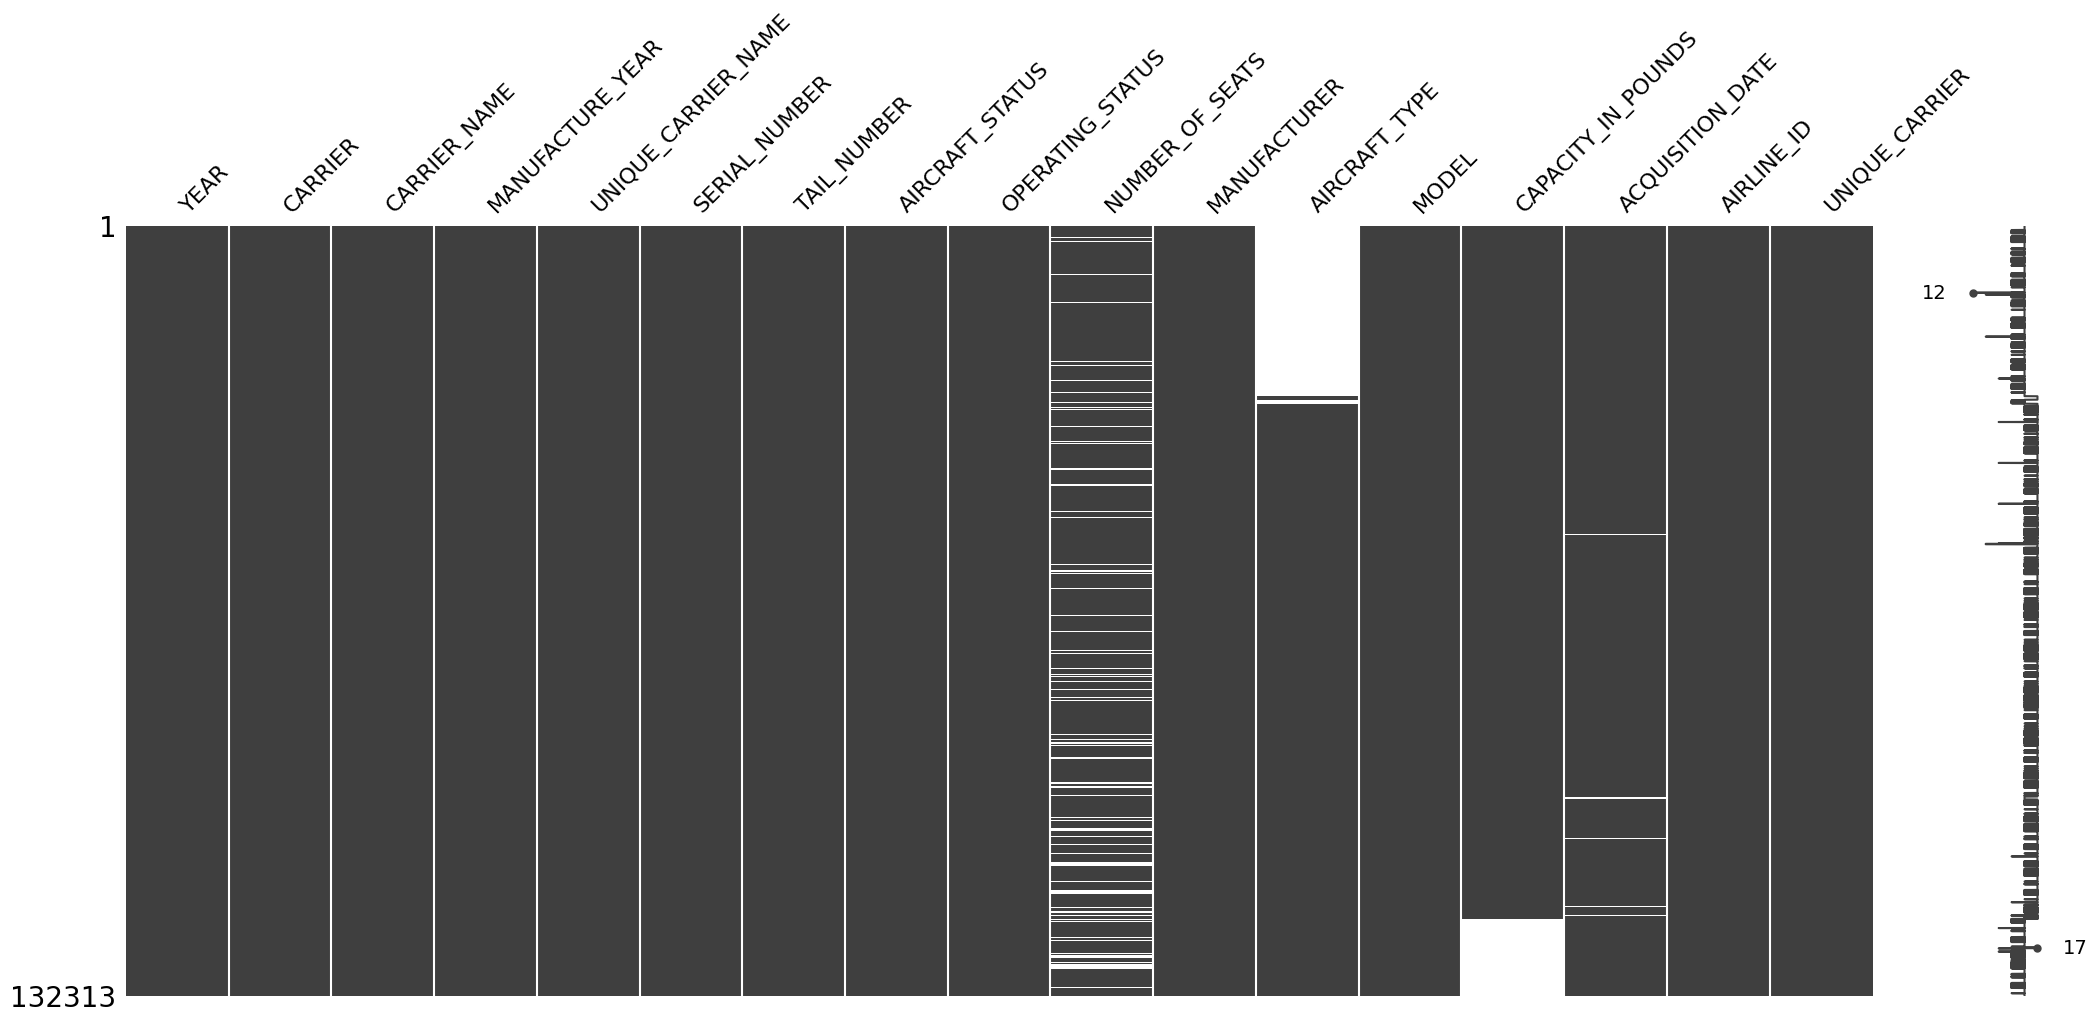

In [154]:
msno.matrix(inventory)

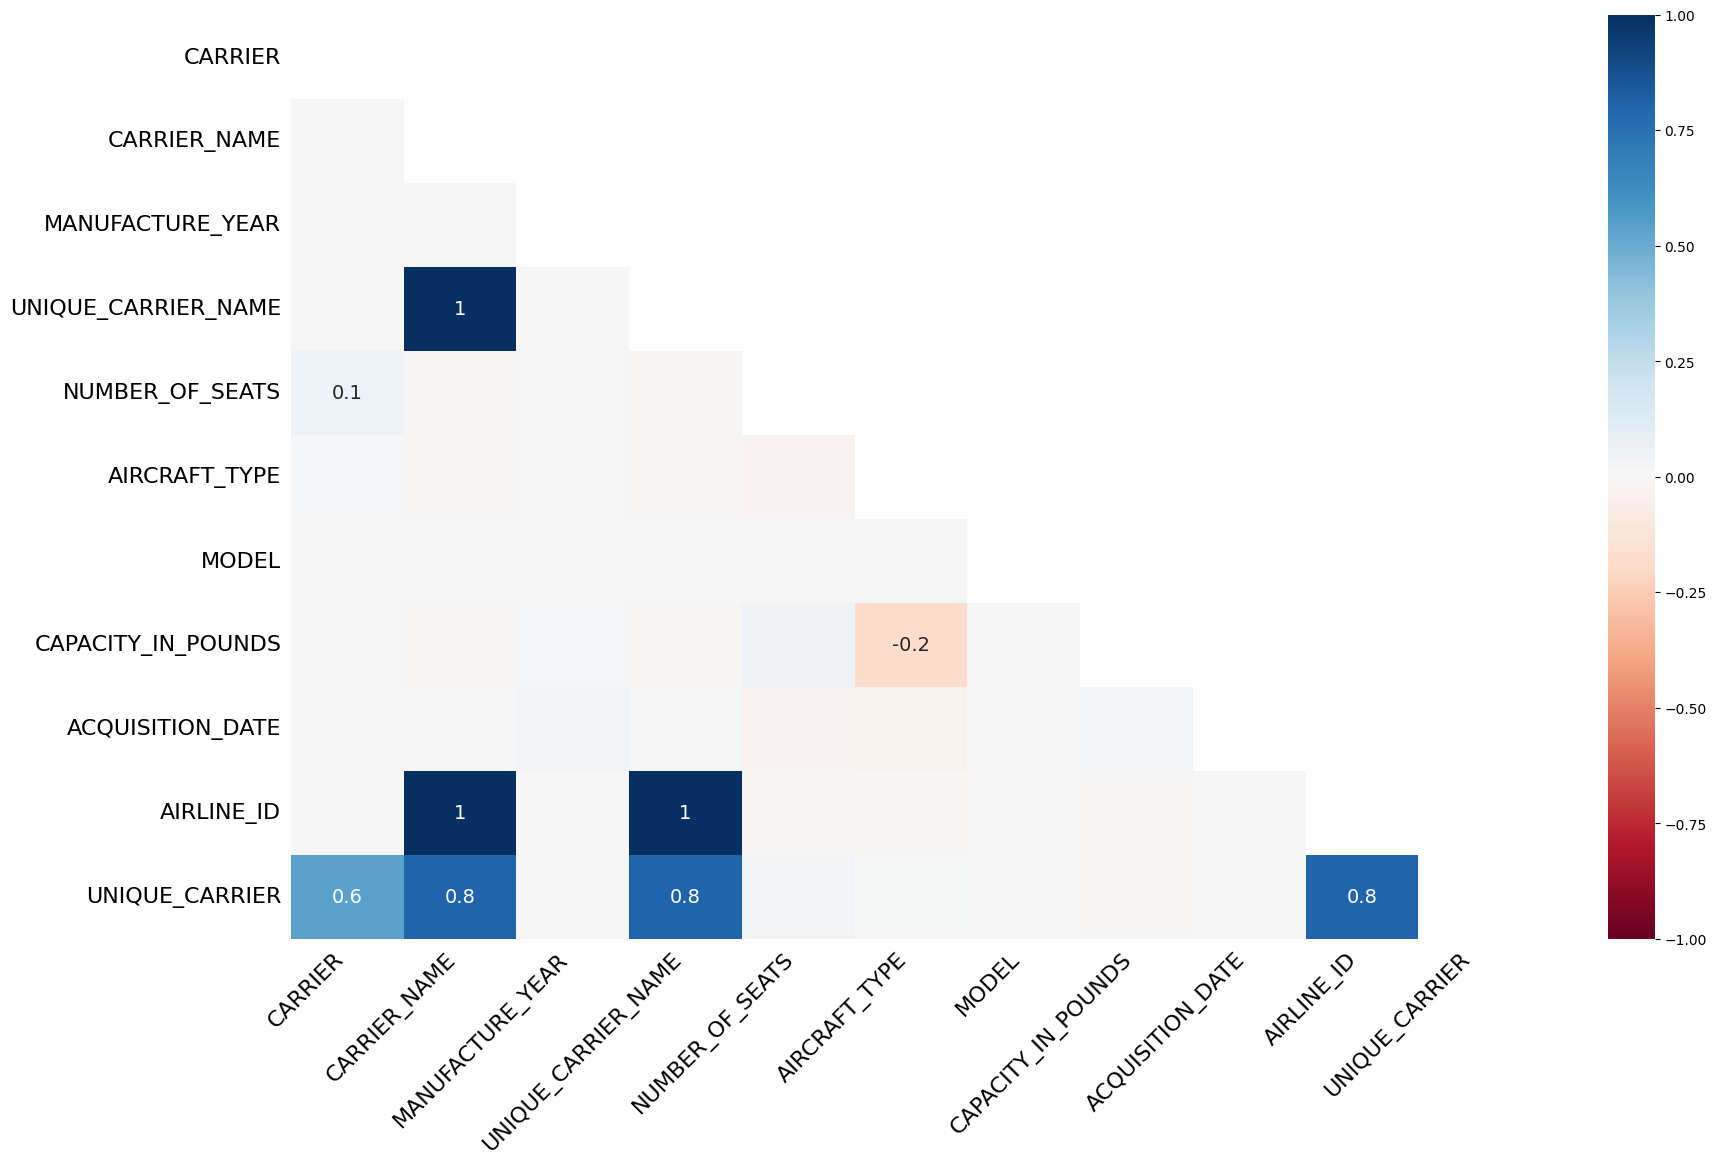

In [155]:
msno.heatmap(inventory)
plt.show()

In [156]:
t1_cols = ['CARRIER', 'CARRIER_NAME', 'MANUFACTURE_YEAR', 'NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS','AIRLINE_ID']
t1 = inventory[t1_cols]

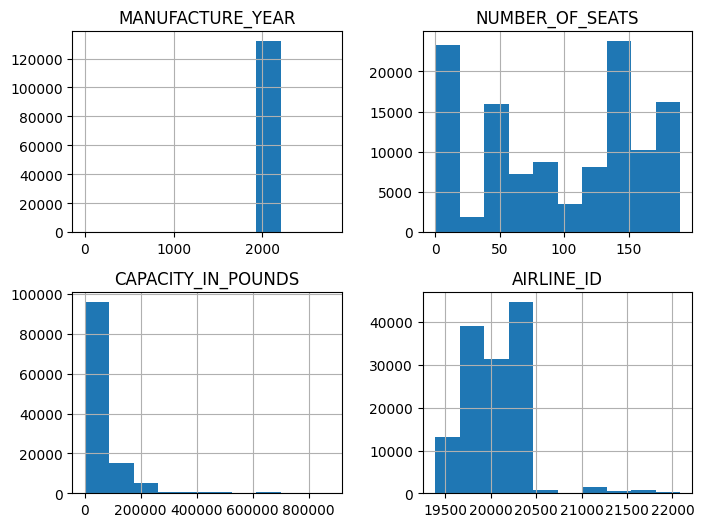

In [157]:
t1.hist(figsize=(8,6))
plt.show()

In [158]:
t1.select_dtypes('str').nunique()

CARRIER         177
CARRIER_NAME    133
dtype: int64

### MANUFACTURE YEAR

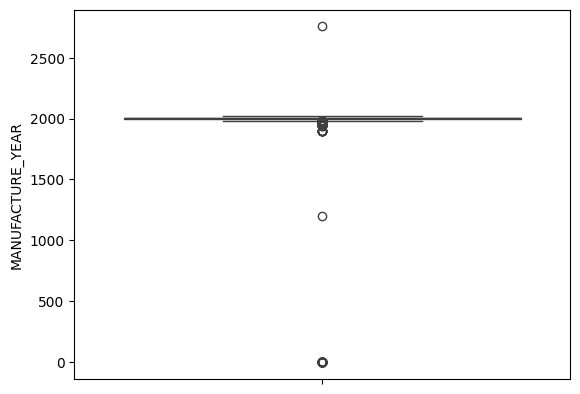

In [159]:
sns.boxplot(t1['MANUFACTURE_YEAR'])
plt.show()

In [160]:
bad_years = inventory.loc[(inventory['MANUFACTURE_YEAR'] < 1940) | (inventory['MANUFACTURE_YEAR'] > 2023) | (inventory['MANUFACTURE_YEAR']).isna()]
bad_years['MANUFACTURE_YEAR'].value_counts(dropna=False)

MANUFACTURE_YEAR
0.0       48
1900.0    10
NaN        3
1197.0     1
2756.0     1
Name: count, dtype: int64

The values above are almost certainly incorrect for the plane's manufacture year. These should all be treated the same. We can impute based on the average manufacture year of that specific plane model.

In [161]:
def impute_manufacture_year(df, min_year=1920, max_year=2023):
    """
    Fill in missing or erroneous values for the `MANUFACTURE_YEAR` column. 
    Use median manufacture year by plane model. Revert to population median 
    otherwise.
    """
    df = df.copy()

    bad_yrs_mask = (
        (df['MANUFACTURE_YEAR'] < min_year) |
        (df['MANUFACTURE_YEAR'] > max_year) |
        (df['MANUFACTURE_YEAR'].isna())
    )

    good_years = df.loc[~bad_yrs_mask]

    model_to_median_yr = (
        good_years.groupby('MODEL')['MANUFACTURE_YEAR']
        .median()
    )

    df.loc[bad_yrs_mask, 'MANUFACTURE_YEAR'] = (
        df.loc[bad_yrs_mask, 'MODEL'].map(model_to_median_yr)
    )

    df['MANUFACTURE_YEAR'] = df['MANUFACTURE_YEAR'].fillna(
        good_years['MANUFACTURE_YEAR'].median()
    )

    df['MANUFACTURE_YEAR'] = df['MANUFACTURE_YEAR'].round().astype('Int64')

    return df

### CAPACITY_IN_POUNDS

In [204]:
inventory.select_dtypes('number').corr()

,YEAR,MANUFACTURE_YEAR,NUMBER_OF_SEATS,CAPACITY_IN_POUNDS,AIRLINE_ID
YEAR,1.000000,0.102218,0.088981,0.139144,0.014090
MANUFACTURE_YEAR,0.102218,1.000000,0.086222,0.005006,0.016751
NUMBER_OF_SEATS,0.088981,0.086222,1.000000,-0.071761,-0.395873
CAPACITY_IN_POUNDS,0.139144,0.005006,-0.071761,1.000000,-0.028323
AIRLINE_ID,0.014090,0.016751,-0.395873,-0.028323,1.000000


In [205]:
pd.crosstab(inventory['YEAR'], inventory['CAPACITY_IN_POUNDS'].isna())

CAPACITY_IN_POUNDS,False,True
YEAR,,
2006,7415,0
2007,7585,0
2008,7117,0
2009,7122,0
2010,7067,0
2011,7170,0
2012,6855,0
2013,6952,0
2014,7060,0


Missing values are almost entirely in 2023 and 2022. This suggests that `CAPACITY_IN_POUNDS` is not MCAR, because it can be explained by `YEAR`. Also, it is likely not MNAR because all of the recent values are missing; it does not depend on the value of the missing entires itself. Therefore, this column is MAR.

#### CAPACITY_IN_POUNDS non-nans

<Axes: >

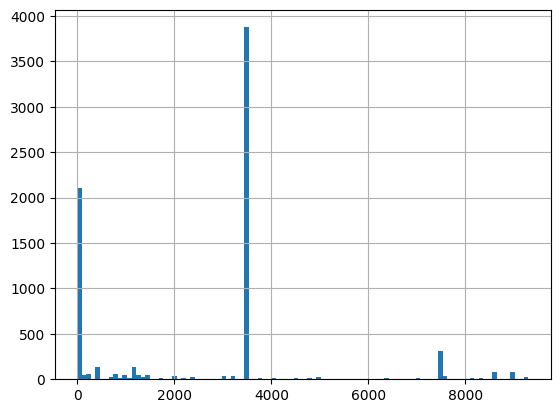

In [254]:
inventory.loc[inventory['CAPACITY_IN_POUNDS'] < 10000, 'CAPACITY_IN_POUNDS'].hist(bins = 100)

In [256]:
inventory.loc[inventory['CAPACITY_IN_POUNDS']  < 2000, 'CAPACITY_IN_POUNDS'].value_counts(dropna=False).sort_index()

CAPACITY_IN_POUNDS
0.0       1972
12.0       137
80.0         2
102.0        2
103.0        5
125.0        9
126.0       11
160.0       22
200.0       53
210.0        2
300.0        4
400.0      140
500.0        4
573.0        2
635.0        1
700.0        6
726.0       20
760.0        3
770.0        3
790.0        1
816.0       48
907.0       16
998.0        2
1000.0      40
1089.0       2
1095.0       3
1100.0       4
1179.0      98
1200.0      33
1270.0      51
1361.0      10
1369.0      14
1451.0      37
1480.0       8
1506.0       6
1600.0       5
1633.0       3
1723.0       6
1724.0       5
1814.0       6
1905.0       4
1980.0       7
1996.0      22
Name: count, dtype: int64

In [245]:
inventory.loc[(inventory['CAPACITY_IN_POUNDS'] < 400) &
              (inventory['CAPACITY_IN_POUNDS'] > 0)].drop_duplicates().sample(20).to_csv('lbs_check.csv')

In [266]:
inventory.loc[(inventory['CAPACITY_IN_POUNDS'] < 1000) &
              (inventory['CAPACITY_IN_POUNDS'] > 400)]

,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
43604,2012,3Z,Tatonduk Outfitters Limited d/b/a Everts Air A...,1964.0,Tatonduk Outfitters Limited d/b/a Everts Air A...,18051077,N5180,O,Y,2.0,Cessna,323,CES-180ECOMBI,700.0,5/1/2003 12:00:00 AM,20408.0,5V
50465,2013,5V,Tatonduk Outfitters Limited d/b/a Everts Air A...,1961.0,Tatonduk Outfitters Limited d/b/a Everts Air A...,18051077,N5180,O,Y,2.0,Cessna,323,CES-180ECOMBI,700.0,5/1/2003 12:00:00 AM,20408.0,5V
57434,2014,5V,Tatonduk Outfitters Limited d/b/a Everts Air A...,1961.0,Tatonduk Outfitters Limited d/b/a Everts Air A...,18051077,N5180,O,Y,2.0,Cessna,323,CES-180ECOMBI,700.0,5/1/2003 12:00:00 AM,20408.0,5V
64407,2015,27Q,"Jet Aviation Flight Services, Inc.",1991.0,"Jet Aviation Flight Services, Inc.",218,N703TM,O,Y,9.0,Dassault,7711,DASSAULT-FALCON-50PS,816.0,1/11/2011 12:00:00 AM,21652.0,27Q
64409,2015,27Q,"Jet Aviation Flight Services, Inc.",2000.0,"Jet Aviation Flight Services, Inc.",304,N909JM,O,Y,9.0,Dassault,7711,DASSAULT-FALCON-50EX,816.0,11/21/2012 12:00:00 AM,21652.0,27Q
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116291,2022,3EQ,"Scott Aviation, LLC d/b/a Silver Air",2010.0,"Scott Aviation, LLC d/b/a Silver Air",50500031,N814SP,O,Y,6.0,Embraer,7461,Phenom300,573.0,6/2/2021 12:00:00 AM,21974.0,3EQ
124016,2022,YV,Mesa Airlines Inc.,2022.0,Mesa Airlines Inc.,VSWX121C0102,N39RR,O,Y,0.0,PIPISTRELDOO,4511,VIRUSSW121C,500.0,10/26/2022 12:00:00 AM,20378.0,YV
124017,2022,YV,Mesa Airlines Inc.,2022.0,Mesa Airlines Inc.,VSWX121C0105,N599RR,O,Y,0.0,PIPISTRELDOO,4511,VIRUSSW121C,500.0,10/26/2022 12:00:00 AM,20378.0,YV
124018,2022,YV,Mesa Airlines Inc.,2022.0,Mesa Airlines Inc.,VSWX121C0106,N91RR,O,Y,0.0,PIPISTRELDOO,4511,VIRUSSW121C,500.0,10/26/2022 12:00:00 AM,20378.0,YV


**Manual Data Check**:
1. MCDONNELLDOUGLAS MD-83 - Maximum takeoff weight is 160k - `CAPACITY_IN_POUNDS` = 160

2. The Cessna Citation Excel (CE-560XL) has a maximum useful load of 7,500 pounds. Its maximum takeoff weight is 20,200 pounds, while the maximum payload (weight of passengers and baggage) is 2,300 pounds. -- `CAPACITY_IN_POUNDS` = 80
3. Embraer E190-100 mf year 2006 - Max takeoff weight ~ 105k - 115k -- `CAPACITY_IN_POUNDS` = 200

4. Douglas 2012 (model is not correct here, there is no model 2012?) - Maximum payload = 20,800, Maximum takeoff weight - 114,600 to 122,000, Cargo compartment = 12,180 -- `CAPACITY_IN_POUNDS` = 12 -- seems to line up with cargo weight, makes sense for FedEx plane

5. JetBlue A320-232 capacity in pounds 37400 -- `CAPACITY_IN_POUNDS` = 400 -- truncated???

6. Gulf Stream G-IV max payload = 3400 -- `CAPACITY_IN_POUNDS` = 400 -- truncated???

7. Pilatus PC-12 NG max payload = 2236 -- `CAPACITY_IN_POUNDS` = 400

8. DASSAULT-FALCON-50EX  max takeoff weight 39700, payload 3320 -- `CAPACITY_IN_POUNDS`

**Analysis**:

Capacity in pounds for values under 500, are almost entirely incorrect. Values under 1000, frequently incorrect. I'm confident the issue also propogates to higher values of `CAPACITY_IN_POUNDS` in someway, but I can't check every data point manually. It also seems like some planes use maximum takeoff weight, passenger weight, or cargo capacity. Some values appear to be truncated, whereas others are off by a factor of 1,000. Also, many values are zero, and I am not sure if this is more data missingness or intentional.


In [ ]:
import numpy as np
import pandas as pd
# model and number_of_seats needs to be cleaned before applying this step
def impute_capacity_in_pounds(df, min_cap=2000, cap_per_seat=225):
    """
    Imputed `CAPACITY_IN_POUNDS` for missing and erroneous values. Select bad values to treat as missing
    by using a minimum capacity `min_cap` and a mulitipler on the capacity based on the number of seats
    `cap_per_seat`. If an observation does not meet either of the thresholds it is treated as missing.

    Imputation methods:
    1. exact model median
    2. same manufactuer + same `SEAT_BIN` median
    2. `SEAT_BIN` median
    4. overall median
    
    Adds:
    - CAPACITY_IN_POUNDS_IMPUTE_METHOD
    """

    df = df.copy()
    seats = df['NUMBER_OF_SEATS']
    cap = df['CAPACITY_IN_POUNDS']

    to_impute_mask = (
        cap.isna() |
        (cap <= 0) |
        (
            seats.notna() &
            (seats > 0) &
            (cap < np.maximum(min_cap, seats * cap_per_seat))
        )
    )

    to_impute_mask = (
    cap.isna() |
    (cap <= 0) |
    (
        seats.notna() &
        (seats > 0) &
        (cap < np.maximum(min_cap, seats * cap_per_seat))
    )
)

    df['CAPACITY_IN_POUNDS_IMPUTE_METHOD'] = np.where(
        to_impute_mask, 'not_imputed_yet', 'original_valid'
    )

    # helper seat bins
    df['SEAT_BIN'] = pd.cut(
        df['NUMBER_OF_SEATS'],
        bins=[-1, 0, 5, 10, 20, 75, 150, np.inf],
        labels=['0', '1-5', '6-10', '11-20', '21-75', '76-150', '151+']
    )

    valid = df.loc[~to_impute_mask].copy()

    # 1) exact model median
    model_median = valid.groupby('MODEL')['CAPACITY_IN_POUNDS'].median()

    model_fill = to_impute_mask & df['MODEL'].map(model_median).notna()
    df.loc[model_fill, 'CAPACITY_IN_POUNDS'] = df.loc[model_fill, 'MODEL'].map(model_median)
    df.loc[model_fill, 'CAPACITY_IN_POUNDS_IMPUTE_METHOD'] = 'model_median'

    # 2) MANUFACTURER + SEAT_BIN median
    still_missing = df['CAPACITY_IN_POUNDS_IMPUTE_METHOD'].eq('not_imputed_yet')

    maker_bin_median = (
        valid.groupby(['MANUFACTURER', 'SEAT_BIN'])['CAPACITY_IN_POUNDS']
        .median()
    )

    maker_bin_keys = df.loc[still_missing, ['MANUFACTURER', 'SEAT_BIN']].apply(tuple, axis=1)
    maker_bin_vals = maker_bin_keys.map(maker_bin_median)

    maker_bin_fill_idx = maker_bin_vals[maker_bin_vals.notna()].index

    df.loc[maker_bin_fill_idx, 'CAPACITY_IN_POUNDS'] = maker_bin_vals.loc[maker_bin_fill_idx]
    df.loc[maker_bin_fill_idx, 'CAPACITY_IN_POUNDS_IMPUTE_METHOD'] = 'manufacturer_seat_bin_median'

    # 3) fallback: seat bin median
    still_missing = df['CAPACITY_IN_POUNDS_IMPUTE_METHOD'].eq('not_imputed_yet')
    seat_bin_median = valid.groupby('SEAT_BIN')['CAPACITY_IN_POUNDS'].median()

    seat_bin_fill = still_missing & df['SEAT_BIN'].map(seat_bin_median).notna()
    df.loc[seat_bin_fill, 'CAPACITY_IN_POUNDS'] = df.loc[seat_bin_fill, 'SEAT_BIN'].map(seat_bin_median)
    df.loc[seat_bin_fill, 'CAPACITY_IN_POUNDS_IMPUTE_METHOD'] = 'seat_bin_median'

    # 4) fallback: overall median
    still_missing = df['CAPACITY_IN_POUNDS_IMPUTE_METHOD'].eq('not_imputed_yet')
    overall_median = valid['CAPACITY_IN_POUNDS'].median()

    df.loc[still_missing, 'CAPACITY_IN_POUNDS'] = overall_median
    df.loc[still_missing, 'CAPACITY_IN_POUNDS_IMPUTE_METHOD'] = 'overall_median'

    return df.drop(columns='SEAT_BIN')

The above function imputes missingness and bad values treated as missing using the median of comparable groups in order of decreasing similarity. The idea is to find planes (with valid `CAPACITY_IN_POUNDS`) as similar as possible to the ones with missing values and use the median from the comaparable as the imputed value.

There are three groups used as comparables:
1. Use the median from planes with the exact same model
2. Use the median from planes from the same manufacturer and similar number of seats
3. Use the median from planes with a similar number of seats (any manufacturer)

If an observation with a missing value does not fall into one of these categories, then the populaton median is used.

This approach is likely preferred over a mice forest because the `CAPACITY_IN_POUNDS` column contains many incorrect values, so the gradient boosting methods would try to recreate the patterns in the contaminated data. This above approach is also preferred over a simple median imputation strategy because there is too much variance in the data for this to be meaningfully descriptive of the missing oservations. 

In [306]:
tmp = inventory.copy()
tmp = impute_capacity_in_pounds(tmp)
tmp['CAPACITY_IN_POUNDS_IMPUTE_METHOD'].value_counts()

CAPACITY_IN_POUNDS_IMPUTE_METHOD
original_valid                  113329
model_median                     11835
manufacturer_seat_bin_median      5901
overall_median                     896
seat_bin_median                    352
Name: count, dtype: int64

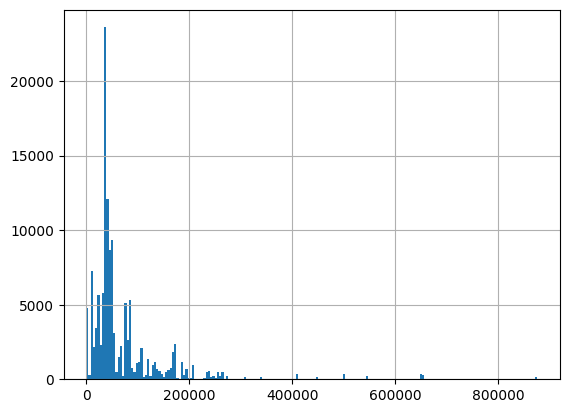

In [315]:
tmp['CAPACITY_IN_POUNDS'].hist(bins=200)
plt.show()

### CARRIER

In [319]:
inventory.loc[inventory['CARRIER'].isna(), ['CARRIER_NAME']].drop_duplicates()

,CARRIER_NAME
11776,North American Airlines


`CARRIER` is only missing for "North American Airlines"

In [329]:
inventory.loc[(inventory['CARRIER_NAME'] == "North American Airlines") &
              ~(inventory['CARRIER'].isna()), 'CARRIER'].drop_duplicates().item()

'NA '

Need to strip extra spaces.

In [333]:
inventory.loc[inventory['CARRIER'].str.contains('NA'), 'CARRIER_NAME'].drop_duplicates()

26207    North American Airlines
Name: CARRIER_NAME, dtype: str

North American Airlines is the only airline that uses `CARRIER` code 'NA'

In [341]:
def impute_carrier(df):
    """
    Fill in missing `CARRIER` with value if it is already known in previous entries. If it is 
    unknown, or the `CARRIER_NAME` has two or more `CARRIER` codes associated with it, the
    value stays as pd.NA
    """
    
    df = df.copy()

    df['CARRIER'] = df['CARRIER'].astype('string').str.strip()
    # treat empty string as NA
    df['CARRIER'] = df['CARRIER'].replace(r'^\s*$', pd.NA, regex=True)
    
    # get mapping from `CARRIER_NAME` to `CARRIER`
    name_to_code = (
    df.dropna(subset=['CARRIER_NAME', 'CARRIER'])
      .groupby('CARRIER_NAME')['CARRIER']
      .agg(lambda s: s.iloc[0] if s.nunique() == 1 else pd.NA)
    )

    to_impute = (
                (df['CARRIER'].isna())
                )

    df.loc[to_impute, 'CARRIER'] = df.loc[to_impute, 'CARRIER_NAME'].map(name_to_code)

    return df


### CARRIER_NAME

In [ ]:
inventory.loc[inventory['CARRIER_NAME'].isna(), ['YEAR', 'CARRIER']].drop_duplicates()

,YEAR,CARRIER
11465,2007,L4
54610,2013,OH


In [362]:
no_name = inventory.loc[inventory['CARRIER_NAME'].isna(), 'CARRIER'].drop_duplicates()
print(no_name)
no_name = no_name.to_list()

11465    L4
54610    OH
Name: CARRIER, dtype: str


In [363]:
inventory.loc[(inventory['CARRIER'].isin(no_name)) &
              ~(inventory['CARRIER_NAME'].isna()), ['YEAR','CARRIER', 'CARRIER_NAME']].drop_duplicates()

,YEAR,CARRIER,CARRIER_NAME
4896,2006,OH,Comair Inc.
12259,2007,OH,Comair Inc.
18739,2008,L4,Lynx Aviation d/b/a Frontier Airlines
19421,2008,OH,Comair Inc.
33726,2010,OH,Comair Inc.
40767,2011,OH,Comair Inc.
68915,2015,OH,PSA Airlines Inc.
76043,2016,OH,PSA Airlines Inc.
83207,2017,OH,PSA Airlines Inc.
90570,2018,OH,PSA Airlines Inc.


Carrier code can be repurposed in the future, e.g. 2011: OH -> Comair Inc., 2015: OH -> PSA Airlines Inc.

Can't just map (`YEAR`, `CARRIER`) -> `CARRIER_NAME` because it could be missing for an entire year.

In [388]:
missing_carriers = inventory.loc[inventory['CARRIER'].isin(no_name), 'CARRIER'].drop_duplicates().to_list()
tn_df = inventory.loc[inventory['CARRIER'].isin(missing_carriers),['CARRIER_NAME','TAIL_NUMBER']]
tn_df['TAIL_NUMBER'] = tn_df['TAIL_NUMBER'].str[-2:]

tn_df.drop_duplicates()

,CARRIER_NAME,TAIL_NUMBER
4896,Comair Inc.,CA
11465,NaN,LX
18739,Lynx Aviation d/b/a Frontier Airlines,LX
54610,NaN,CA
68915,PSA Airlines Inc.,AE
68924,PSA Airlines Inc.,PS
68947,PSA Airlines Inc.,JS
68973,PSA Airlines Inc.,EA
68974,PSA Airlines Inc.,PB
68975,PSA Airlines Inc.,FF


The missing entries are likely Lynx and Comair (not PSA). The tail numbers end in 2-letter codes which can be used to differentiate the plane's carrier.

In [390]:
def impute_carrier_name(df):
    """
    Use existing observations to create mapping (CARRIER, TAIL_SUFFIX) -> CARRIER_NAME
    Leave empty if map doesn't exist or conflicts exist
    """
    df = df.copy()

    df['CARRIER'] = df['CARRIER'].astype('string').str.strip()
    df['TAIL_NUMBER'] = df['TAIL_NUMBER'].astype('string').str.strip()

    # treat empty string as nan    
    df['CARRIER_NAME'] = df['CARRIER_NAME'].replace(r'^\s*$', pd.NA, regex=True)
    df['TAIL_NUMBER'] = df['TAIL_NUMBER'].replace(r'^\s*$', pd.NA, regex=True)

    df['TAIL_SUFFIX'] = df['TAIL_NUMBER'].str[-2:]

    # map TAIL_SUFFIX and CARRIER to CARRIER_NAME, keep nan if conflicts
    mapping = (
        df.dropna(subset=['CARRIER', 'TAIL_SUFFIX', 'CARRIER_NAME'])
          .groupby(['CARRIER', 'TAIL_SUFFIX'])['CARRIER_NAME']
          .agg(lambda s: s.iloc[0] if s.nunique() == 1 else pd.NA)
    )

    # fill only missing names
    to_impute = (
        df['CARRIER_NAME'].isna() &
        df['CARRIER'].notna() &
        df['TAIL_SUFFIX'].notna()
    )


    df.loc[to_impute, 'CARRIER_NAME'] = (
        df.loc[to_impute, ['CARRIER', 'TAIL_SUFFIX']]
          .apply(tuple, axis=1)
          .map(mapping)
    )

    return df.drop(columns='TAIL_SUFFIX')

In [ ]:
tmp = inventory.copy()
tmp = impute_carrier_name(tmp)
tmp.loc[tmp['CARRIER_NAME'].isna()]

In [394]:
tmp.iloc[54610]['CARRIER_NAME']

'Comair Inc.'

### NUMBER OF SEATS

Is there a pattern for when number of seats is missing?:
- Are there certain carriers who do not report number of seats?
- Are there certain types of planes who do not report number of seats?
- Are there planes with zero seats (passenger)?
    - Yes some small private planes only have 2 crew seats. 


<Axes: >

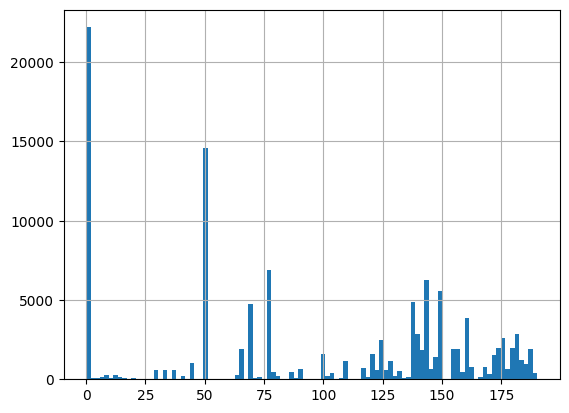

In [479]:
inventory['NUMBER_OF_SEATS'].hist(bins=100)

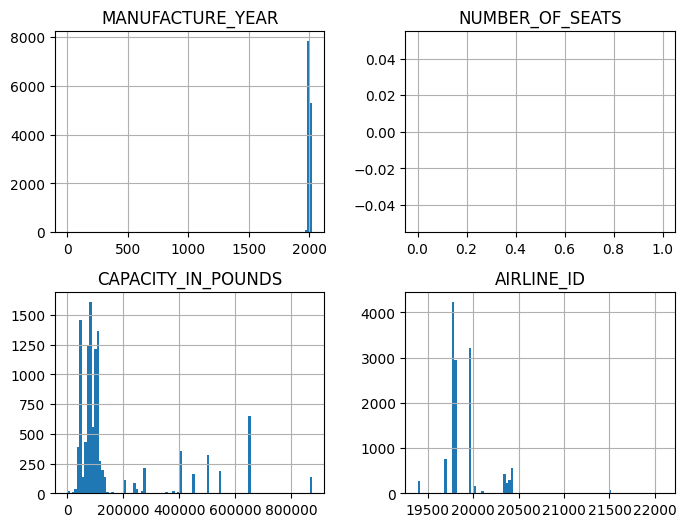

In [395]:
no_seats_df = t1.loc[t1['NUMBER_OF_SEATS'].isna()]
no_seats_df.hist(figsize=(8,6), bins=100)
plt.show()

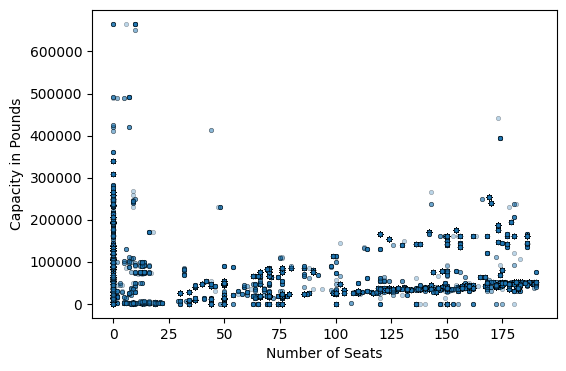

In [435]:
plt.figure(figsize=(6,4))
plt.scatter(x=inventory['NUMBER_OF_SEATS'], y=inventory['CAPACITY_IN_POUNDS'], 
            alpha=0.3,
            edgecolors='black',
            linewidths=0.5,
            s=10)
plt.xlabel('Number of Seats')
plt.ylabel('Capacity in Pounds')
plt.show()

<Axes: ylabel='MANUFACTURE_YEAR'>

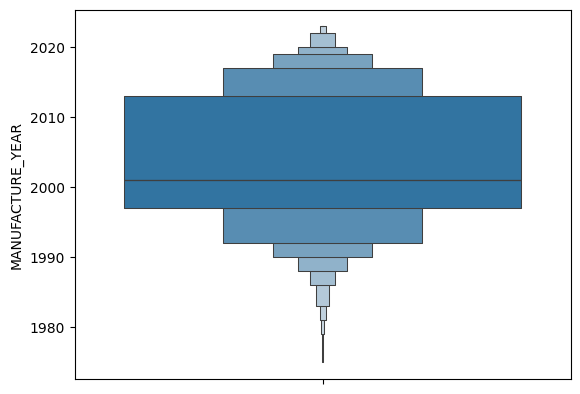

In [447]:
sns.boxenplot(no_seats_df['MANUFACTURE_YEAR'], showfliers=False)

<Axes: ylabel='MANUFACTURE_YEAR'>

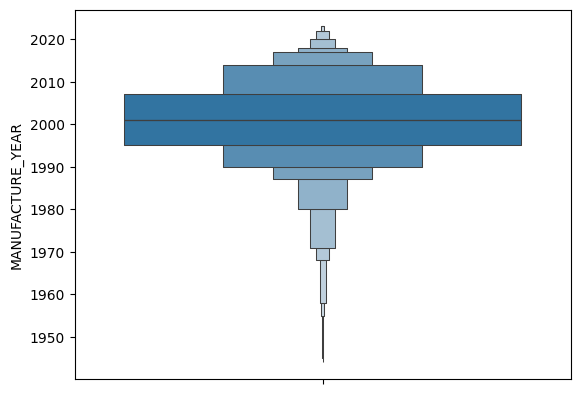

In [461]:
sns.boxenplot(inventory['MANUFACTURE_YEAR'].sort_values(ascending=False).iloc[:-60], showfliers=False)

In [478]:
no_seats_df.apply(pd.Series.nunique)

CARRIER                38
CARRIER_NAME           29
MANUFACTURE_YEAR       49
NUMBER_OF_SEATS         0
CAPACITY_IN_POUNDS    264
AIRLINE_ID             27
dtype: int64

AUC: 0.8199334402332176
Classification 0.9313003060877452
Recall (missing class): 0.4059667673716012


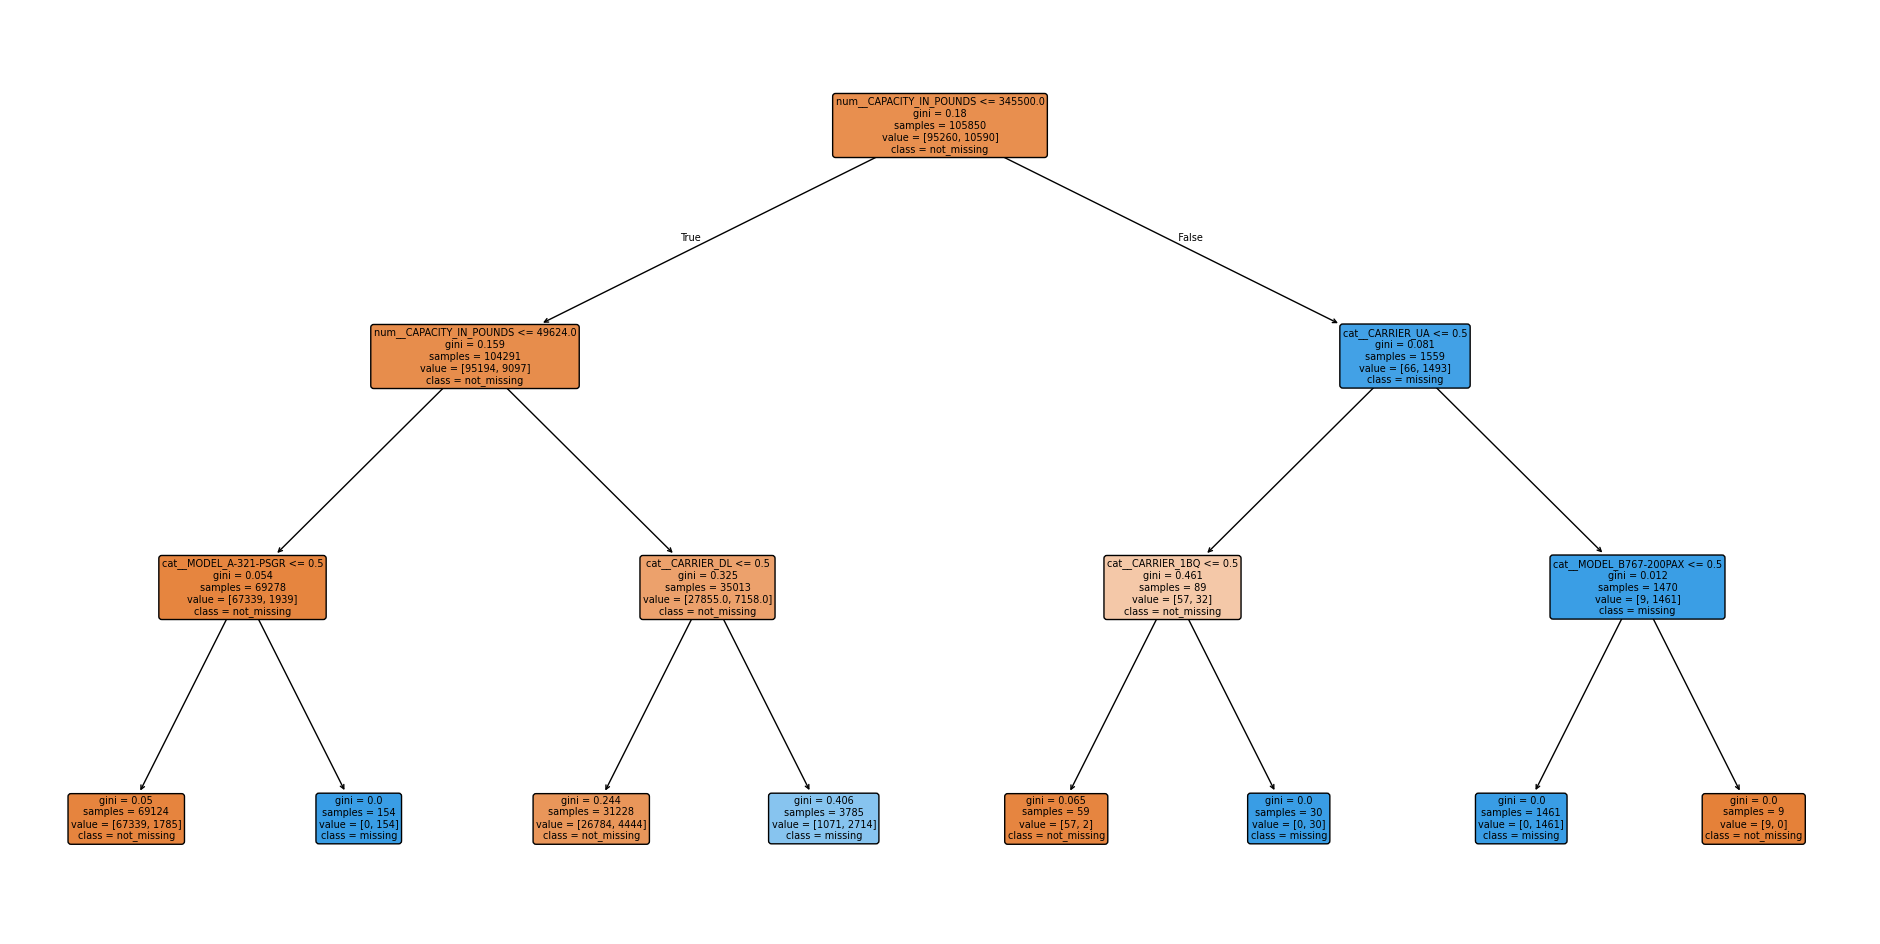

In [554]:
def pred_seats(inventory):
    df = inventory.copy()

    # is NUMBER_OF_SEATS missing?
    df['seats_missing'] = df['NUMBER_OF_SEATS'].isna().astype(int)

    features = [
        'MANUFACTURER',
        'MODEL',
        'CARRIER',
        'AIRCRAFT_STATUS',
        'OPERATING_STATUS',
        'MANUFACTURE_YEAR',
        'CAPACITY_IN_POUNDS'
    ]

    X = df[features]
    y = df['seats_missing']

    cat_cols = X.select_dtypes(include=['object', 'string', 'category']).columns
    num_cols = X.select_dtypes(include=['number', 'bool']).columns

    preprocess = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    tree_model = Pipeline([
        ('prep', preprocess),
        ('clf', DecisionTreeClassifier(max_depth=3, random_state=42))
    ])

    tree_model.fit(X_train, y_train)
    probs = tree_model.predict_proba(X_test)[:, 1]
    preds = tree_model.predict(X_test)

    print("AUC:", roc_auc_score(y_test, probs))

    print('Classification', accuracy_score(y_test, preds))

    print("Recall (missing class):", recall_score(y_test, preds, pos_label=1))
    prep = tree_model.named_steps['prep']
    tree_clf = tree_model.named_steps['clf']

    feature_names = prep.get_feature_names_out()

    plt.figure(figsize=(24, 12))
    plot_tree(
        tree_clf,
        feature_names=feature_names,
        class_names=['not_missing', 'missing'],
        filled=True,
        rounded=True,
        fontsize=7,
        max_depth=3
    )
    plt.show()

pred_seats(inventory)

`NUMBER_OF_SEATS` appears to be MCAR. There is not another feature or set of features that can explain missingness, which can be seen from the performance of the decision tree. The accuracy of 0.93 is misleading as the class balance is 10% missing 90% not missing. The mediocre performance can be seen from recall, which implies that only 40% of missing entries are identified. Therefore, it is likely not MAR. Since there is no clear structural pattern, there is also little evidence that it is MNAR, because if the missingness were systematically related to the underlying number of seats, we would likely expect at least some stronger pattern in the observed features or in model performance. Thus, MCAR is the most reasonable classification for `NUMBER_OF_SEATS`.

In [ ]:
import numpy as np
import pandas as pd

def impute_number_of_seats(df):
    """
    Impute `NUMBER_OF_SEATS` using comparables of decreasing similarity:
    1. exact MODEL mode
    2. AIRCRAFT_TYPE mode
    3. overall median

    Adds: `NUMBER_OF_SEATS_IMPUTE_METHOD`
    """
    df = df.copy()

    df['NUMBER_OF_SEATS_IMPUTE_METHOD'] = np.where(
        df['NUMBER_OF_SEATS'].isna(),
        'not_imputed_yet',
        'original_valid'
    )

    def first_mode(s):
        m = s.mode()
        return m.iloc[0] if not m.empty else pd.NA

    # 1) exact MODEL mode
    model_mode = (
        df.dropna(subset=['MODEL', 'NUMBER_OF_SEATS'])
          .groupby('MODEL')['NUMBER_OF_SEATS']
          .agg(first_mode)
    )

    mask = df['NUMBER_OF_SEATS_IMPUTE_METHOD'].eq('not_imputed_yet')
    fill = df.loc[mask, 'MODEL'].map(model_mode)
    idx = fill[fill.notna()].index

    df.loc[idx, 'NUMBER_OF_SEATS'] = fill.loc[idx]
    df.loc[idx, 'NUMBER_OF_SEATS_IMPUTE_METHOD'] = 'model_mode'

    # 2) AIRCRAFT_TYPE mode
    aircraft_type_mode = (
        df.dropna(subset=['AIRCRAFT_TYPE', 'NUMBER_OF_SEATS'])
          .groupby('AIRCRAFT_TYPE')['NUMBER_OF_SEATS']
          .agg(first_mode)
    )

    mask = df['NUMBER_OF_SEATS_IMPUTE_METHOD'].eq('not_imputed_yet')
    fill = df.loc[mask, 'AIRCRAFT_TYPE'].map(aircraft_type_mode)
    idx = fill[fill.notna()].index

    df.loc[idx, 'NUMBER_OF_SEATS'] = fill.loc[idx]
    df.loc[idx, 'NUMBER_OF_SEATS_IMPUTE_METHOD'] = 'aircraft_type_mode'

    # 3) MANUFACTURER mode
    manufacturer_mode = (
    df.dropna(subset=['MANUFACTURER', 'NUMBER_OF_SEATS'])
        .groupby('MANUFACTURER')['NUMBER_OF_SEATS']
        .agg(first_mode)
    )

    mask = df['NUMBER_OF_SEATS_IMPUTE_METHOD'].eq('not_imputed_yet')
    fill = df.loc[mask, 'MANUFACTURER'].map(manufacturer_mode)
    idx = fill[fill.notna()].index
    df.loc[idx, 'NUMBER_OF_SEATS'] = fill.loc[idx]
    df.loc[idx, 'NUMBER_OF_SEATS_IMPUTE_METHOD'] = 'manufacturer_mode'


    # 4) overall mode
    mask = df['NUMBER_OF_SEATS_IMPUTE_METHOD'].eq('not_imputed_yet')
    overall_mode = df['NUMBER_OF_SEATS'].mode()

    df.loc[mask, 'NUMBER_OF_SEATS'] = overall_mode
    df.loc[mask, 'NUMBER_OF_SEATS_IMPUTE_METHOD'] = 'overall_mode'

    return df

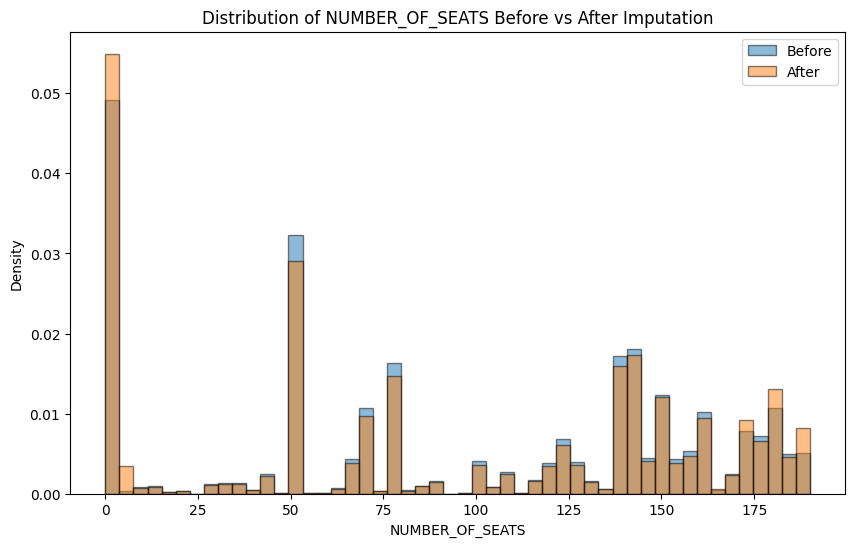

In [ ]:
tmp = inventory.copy()
tmp = impute_number_of_seats(tmp)
before = inventory['NUMBER_OF_SEATS'].dropna()
after = tmp['NUMBER_OF_SEATS'].dropna()

# need to share bins across dataframes so bars line up
bins = np.histogram_bin_edges(pd.concat([before, after]), bins=50)

plt.figure(figsize=(10, 6))
plt.hist(before, bins=bins, alpha=0.5, density=True, label='Before', edgecolor='black')
plt.hist(after, bins=bins, alpha=0.5, density=True, label='After', edgecolor='black')
plt.xlabel('NUMBER_OF_SEATS')
plt.ylabel('Density')
plt.title('Distribution of NUMBER_OF_SEATS Before vs After Imputation')
plt.legend()
plt.show()

In [569]:
tmp['NUMBER_OF_SEATS_IMPUTE_METHOD'].value_counts()

NUMBER_OF_SEATS_IMPUTE_METHOD
original_valid        119075
model_mode              4839
aircraft_type_mode      4370
manufacturer_mode       4028
overall_median             1
Name: count, dtype: int64

The `NUMBER_OF_SEATS` column is imputed using the mode of comparables, if they exist, in decreasing order of similarity. Mode is chosen here because number of seats is a discrete label with repeated configurations. This results in the imputted value being a commonly observed seating configuration.

### AIRLINE_ID

From the general EDA, we can see that `AIRLINE_ID` is missing exactly when `CARRIER_NAME` is missing. Also according to the data description, it seems that there is a one-to-one relationship between `CARRIER_NAME` and `AIRLINE_ID`.

In [585]:
inventory.groupby('CARRIER_NAME')['AIRLINE_ID'].nunique().value_counts()

AIRLINE_ID
1    131
2      2
Name: count, dtype: int64

In [591]:
print(inventory.groupby('CARRIER_NAME')['AIRLINE_ID'].nunique().sort_values(ascending=False).head(2))

mul_cars = inventory.groupby('CARRIER_NAME')['AIRLINE_ID'].nunique().sort_values(ascending=False).head(2).index.to_list()

CARRIER_NAME
ExpressJet Airlines Inc.    2
Aloha Air Cargo             2
Name: AIRLINE_ID, dtype: int64


In [593]:
inventory.loc[inventory['CARRIER_NAME'].isin(mul_cars), ['CARRIER_NAME', 'AIRLINE_ID']].drop_duplicates()

,CARRIER_NAME,AIRLINE_ID
6830,ExpressJet Airlines Inc.,20374.0
16363,Aloha Air Cargo,19678.0
33338,Aloha Air Cargo,21634.0
45956,ExpressJet Airlines Inc.,20366.0


Mostly true that it is 1-to-1. Leave nan if there are conflicts.

In [576]:
inventory.loc[inventory['CARRIER'].isin(no_name), ['CARRIER','AIRLINE_ID']].drop_duplicates()

,CARRIER,AIRLINE_ID
4896,OH,20417.0
11465,L4,NaN
18739,L4,21217.0
54610,OH,NaN
68915,OH,20397.0


In [582]:
tmp = inventory.copy()
tmp = impute_carrier(tmp)
tmp = impute_carrier_name(tmp)

tmp.loc[tmp['CARRIER'].isin(no_name), ['CARRIER_NAME', 'AIRLINE_ID']].drop_duplicates()

,CARRIER_NAME,AIRLINE_ID
4896,Comair Inc.,20417.0
11465,Lynx Aviation d/b/a Frontier Airlines,NaN
18739,Lynx Aviation d/b/a Frontier Airlines,21217.0
54610,Comair Inc.,NaN
68915,PSA Airlines Inc.,20397.0


In [610]:
# run this after CARRIER and CARRIER_NAME have been imputed
def impute_airline_id(df):
    df = df.copy()

    df['AIRLINE_ID'] = pd.to_numeric(df['AIRLINE_ID'], errors='coerce').astype('Float64')

    # map CARRIER_NAME to AIRLINE_ID
    mapping = (
        df.dropna(subset=['CARRIER_NAME', 'AIRLINE_ID'])
          .groupby('CARRIER_NAME')['AIRLINE_ID']
          .agg(lambda s: s.iloc[0] if s.nunique() == 1 else pd.NA)
    )

    mask = df['AIRLINE_ID'].isna()
    df.loc[mask, 'AIRLINE_ID'] = df.loc[mask, 'CARRIER_NAME'].map(mapping).astype('Float64')

    return df

# Task 2

For each of `MANUFACTURER`, `MODEL`, `AIRCRAFT_STATUS`, and `OPERATING_STATUS`, inspect the raw values with `value_counts()` to decide whether standardization is needed. The two status columns are categorical, so capitalization and whitespace fixes are sufficient. `MANUFACTURER` and `MODEL` are very messy: for these we use `value_counts()` rather than attempting to catch every variant.

### AIRCRAFT_STATUS

Aircraft Statuts - 'A' = Capital Lease, 'B' = Operating Lease, 'O' = Owned

In [595]:
inventory['AIRCRAFT_STATUS'].value_counts(dropna=False)

AIRCRAFT_STATUS
O    79487
b    30852
B    12699
a     7804
A     1330
L      122
o       19
Name: count, dtype: int64

Both versions appear (`A`/`a`, `B`/`b`, `O`/`o`), and there are 122 rows with value `'L'`, which is not a unknwon code? Standardization is needed

1. Uppercase everything
2. Treat `'L'` as unknown and set it to `pd.NA`. `'L'` is not in the published code list, and all 122 instances are on a single carrier in a single year.

In [ ]:
def standardize_aircraft_status(df):
    df = df.copy()
    s = df['AIRCRAFT_STATUS'].astype('string').str.strip().str.upper()
    s = s.where(s.isin(['A', 'B', 'O']), pd.NA)
    df['AIRCRAFT_STATUS'] = s
    return df

tmp = standardize_aircraft_status(inventory)
tmp['AIRCRAFT_STATUS'].value_counts(dropna=False)

AIRCRAFT_STATUS
O       79506
B       43551
A        9134
<NA>      122
Name: count, dtype: int64[pyarrow]

### OPERATING_STATUS

Expected to be a Y/N flag.

In [597]:
inventory['OPERATING_STATUS'].value_counts(dropna=False)

OPERATING_STATUS
Y    126577
N      5664
y        71
          1
Name: count, dtype: int64

mostly `'Y'` and `'N'`, but there are 71 `'y'` entries and 1 value empty string.

1. Strip whitespace and uppercase
2. Everything else becomes `pd.NA`

In [598]:
def standardize_operating_status(df):
    df = df.copy()
    s = df['OPERATING_STATUS'].astype('string').str.strip().str.upper()
    s = s.where(s.isin(['Y', 'N']), pd.NA)
    df['OPERATING_STATUS'] = s
    return df

tmp = standardize_operating_status(inventory)
tmp['OPERATING_STATUS'].value_counts(dropna=False)

OPERATING_STATUS
Y       126648
N         5664
<NA>         1
Name: count, dtype: int64[pyarrow]

### MANUFACTURER

In [599]:
print('unique values:', inventory['MANUFACTURER'].nunique())
inventory['MANUFACTURER'].value_counts(dropna=False).head(25)

unique values: 183


MANUFACTURER
BOEING                                                                              15922
Embraer                                                                             11508
THEBOEINGCO                                                                          9223
Bombardier                                                                           8871
Boeing                                                                               8392
BoeingCo                                                                             7446
AIRBUS                                                                               7179
AirbusIndustries                                                                     6967
BOEINGCOMPANY                                                                        6767
Airbus                                                                               5289
CESSNA                                                                               41

a lot of duplicates for the same manufacturer. 

to fix:
1. Trailing whitespace
2. capitalization
3. Punctuation / dashes
4. Company naming variants

In [ ]:
import re

# 1) strip, uppercase, drop non-alphanumeric
mfr_step1 = (
    inventory['MANUFACTURER']
    .astype('string')
    .str.strip()
    .str.upper()
    .str.replace(r'[^A-Z0-9]', '', regex=True)
)

print('Step 1 (strip / upper / alnum-only) unique:', mfr_step1.nunique())
mfr_step1.value_counts().head(15)

Step 1 (strip / upper / alnum-only) unique: 131


MANUFACTURER
BOEING              27159
EMBRAER             15554
AIRBUS              13440
BOMBARDIER          11834
THEBOEINGCO          9231
MCDONNELLDOUGLAS     8465
BOEINGCO             8385
AIRBUSINDUSTRIES     7053
BOEINGCOMPANY        6767
CESSNA               4514
THEBOEINGCOMPANY     3975
CANADAIR             3861
AIRBUSINDUSTRIE      2666
ATR                  1181
DOUGLAS              1137
Name: count, dtype: int64[pyarrow]

In [602]:
# 2) keyword consolidation
MANUFACTURER_PATTERNS = [
    ('BOEING',            r'BOEING'),
    ('AIRBUS',            r'AIRBUS'),
    ('MCDONNELLDOUGLAS',  r'MCDONNEL|MCDO'),     
    ('EMBRAER',           r'EMBRAER'),
    ('BOMBARDIER',        r'BOMBARDIER'),
    ('CANADAIR',          r'CANADAIR'),         
    ('DOUGLAS',           r'DOUGLAS'),
    ('CESSNA',            r'CESSNA'),
    ('DEHAVILLAND',       r'DEHAVILLAND|HAVILLAND'),
    ('ATR',               r'^ATR$|^ATR[0-9]'),
    ('SAAB',              r'SAAB'),
    ('GULFSTREAM',        r'GULFSTREAM'),
    ('LOCKHEED',          r'LOCKHEED'),
    ('DASSAULT',          r'DASSAULT'),
    ('DORNIER',           r'DORNIER'),
    ('CONVAIR',           r'CONVAIR'),
]

def consolidate_manufacturer(value):
    if pd.isna(value):
        return value
    for canonical, pattern in MANUFACTURER_PATTERNS:
        if re.search(pattern, value):
            return canonical
    return value

def standardize_manufacturer(df):
    """
    Clean MANUFACTURER in two passes:
    1. strip, uppercase, remove non-alphanumeric
    2. keyword consolidation
    """
    df = df.copy()
    cleaned = (
        df['MANUFACTURER']
        .astype('string')
        .str.strip()
        .str.upper()
        .str.replace(r'[^A-Z0-9]', '', regex=True)
    )
    df['MANUFACTURER'] = cleaned.map(consolidate_manufacturer)
    return df

tmp = standardize_manufacturer(inventory)
print('After full cleaning unique:', tmp['MANUFACTURER'].nunique())
tmp['MANUFACTURER'].value_counts(dropna=False).head(20)

After full cleaning unique: 104


MANUFACTURER
BOEING              55639
AIRBUS              23517
EMBRAER             15554
BOMBARDIER          12483
MCDONNELLDOUGLAS     9353
CESSNA               4514
CANADAIR             3861
DOUGLAS              1459
ATR                  1181
GE                   1110
DEHAVILLAND          1084
SAAB                  600
GULFSTREAM            446
CONVAIR               208
LOCKHEED              158
DASSAULT              138
DORNIER               100
CURTISS                46
DASSULTSUD             45
EASYJETGOAL            44
Name: count, dtype: int64

### MODEL

In [603]:
print('unique values:', inventory['MODEL'].nunique())
inventory['MODEL'].value_counts(dropna=False).head(25)

unique values: 1340


MODEL
EMB-145                 2614
B-737-7H4               2470
B737-823                2370
A320-232                2333
A321-231                2259
737-700PASSENGERONLY    2027
C-208B                  1872
B757-2                  1775
CRJ-2/4                 1761
B737-800PAX             1621
MD-80                   1610
ERJ-170-200LR           1379
757-200                 1345
CRJ200-2B19             1342
A319                    1267
B-737-8H4               1256
CRJ-200                 1148
ERJ-175                 1132
SUPER80PASSENGER        1108
A320-1/2                1107
757-24APF               1039
B737-3                  1036
MD-88-PSGR              1028
C-208B/3                1017
MD-11                    991
Name: count, dtype: int64

messier than `MANUFACTURER`

to fix:
1. Inconsistent prefixes and separators
2. Suffixes describing configuration e.g. "PASSENGERONLY".
3. capitalization, whitespace, punctuation

In [604]:
def standardize_model(df):
    """
    1. strip, uppercase
    2. drop trailing passenger configuration tags
    """
    df = df.copy()
    s = df['MODEL'].astype('string').str.strip().str.upper()

    # remove trailing config 
    config_tail = r'[-/ ]?(PASSENGERONLY|PASSENGER|PSGR|PAX|COMBI)$'
    s = s.str.replace(config_tail, '', regex=True)

    # collapse internal whitespace
    s = s.str.replace(r'\s+', '', regex=True)

    df['MODEL'] = s
    return df

tmp = standardize_model(inventory)
print('Before:', inventory['MODEL'].nunique(), 'unique models')
print('After :', tmp['MODEL'].nunique(), 'unique models')
tmp['MODEL'].value_counts(dropna=False).head(15)

Before: 1340 unique models
After : 1132 unique models


MODEL
B737-823     3326
EMB-145      2976
B-737-7H4    2474
A320-232     2463
A321-231     2298
737-700      2044
CRJ-200      2009
C-208B       1901
B737-800     1874
B757-2       1775
CRJ-2/4      1761
MD-80        1611
SUPER80      1589
A320-1/2     1466
757-200      1442
Name: count, dtype: int64[pyarrow]

### Apply Imputation and Standardization

1. Standardize the 4 text columns
2. Impute carriers `CARRIER`, `CARRIER_NAME`, and then `AIRLINE_ID`.
3. Impute numeric `MANUFACTURE_YEAR`, `NUMBER_OF_SEATS`, and then`CAPACITY_IN_POUNDS`.

In [612]:
clean = inventory.copy()
# 1) Standardize text
clean = standardize_aircraft_status(clean)
clean = standardize_operating_status(clean)
clean = standardize_manufacturer(clean)
clean = standardize_model(clean)

# 2) carriers
clean = impute_carrier(clean)
clean = impute_carrier_name(clean)
clean = impute_airline_id(clean)

# 3) Numeric 
clean = impute_manufacture_year(clean)
clean = impute_number_of_seats(clean)
clean = impute_capacity_in_pounds(clean)



# missingness check
print("Missing Values per column:")
pd.concat(
    [inventory.isna().sum().rename('before'),
     clean[inventory.columns].isna().sum().rename('after')],
    axis=1
)

Missing Values per column:


,before,after
YEAR,0,0
CARRIER,49,0
CARRIER_NAME,105,0
MANUFACTURE_YEAR,3,0
UNIQUE_CARRIER_NAME,105,105
SERIAL_NUMBER,0,0
TAIL_NUMBER,0,0
AIRCRAFT_STATUS,0,122
OPERATING_STATUS,0,1
NUMBER_OF_SEATS,13238,0


# Task 3

In [627]:
before = len(clean)
clean_dropped = clean.dropna(subset=inventory.columns)
after = len(clean_dropped)

print(f'rows before drop: {before:,}')
print(f'rows after drop: {after:,}')

rows before drop: 132,313
rows after drop: 101,153


# Task 4

In [628]:
from scipy import stats

num_cols = ['NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS']

print('Skewness before Boxcox:')
for col in num_cols:
    print(f'{col:} {clean_dropped[col].skew():.3f}')

Skewness before Boxcox:
NUMBER_OF_SEATS -0.222
CAPACITY_IN_POUNDS 4.043


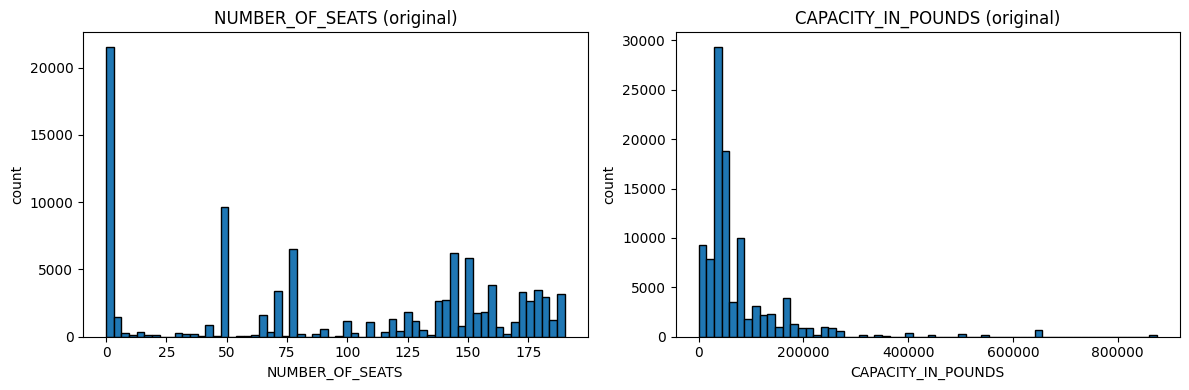

In [629]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, num_cols):
    ax.hist(clean_dropped[col], bins=60, edgecolor='black')
    ax.set_title(f'{col} (original)')
    ax.set_xlabel(col)
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

In [630]:
transformed = clean_dropped.copy()

# boxcox needs positive values
seats_shifted = transformed['NUMBER_OF_SEATS'].astype(float) + 1
seats_bc, lam_seats = stats.boxcox(seats_shifted)
transformed['NUMBER_OF_SEATS_BOXCOX'] = seats_bc

cap = transformed['CAPACITY_IN_POUNDS'].astype(float)
cap_bc, lam_cap = stats.boxcox(cap)
transformed['CAPACITY_IN_POUNDS_BOXCOX'] = cap_bc

print('Skewness after BC:')
for col in ['NUMBER_OF_SEATS_BOXCOX', 'CAPACITY_IN_POUNDS_BOXCOX']:
    print(f'{col:} {transformed[col].skew():.3f}')

Skewness after BC:
NUMBER_OF_SEATS_BOXCOX -0.646
CAPACITY_IN_POUNDS_BOXCOX 0.114


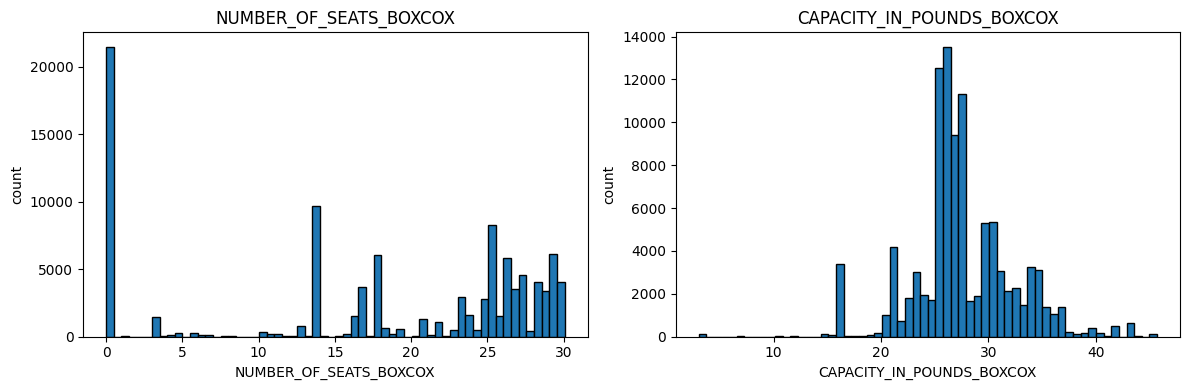

In [631]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['NUMBER_OF_SEATS_BOXCOX', 'CAPACITY_IN_POUNDS_BOXCOX']):
    ax.hist(transformed[col], bins=60, edgecolor='black')
    ax.set_title(f'{col}')
    ax.set_xlabel(col)
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

**Observations**

- *Before transformation*: `CAPACITY_IN_POUNDS` is strongly right-skewed (skewness ≈ **4.0**) — a handful of very-heavy cargo aircraft stretch a long right tail. `NUMBER_OF_SEATS` is much closer to symmetric (skew ≈ **−0.2**), but its distribution is clearly *bimodal* rather than normal: a large spike near zero from cargo/freight aircraft (whose zeros the imputer leaves untouched) and a second mass clustered around the ~150-seat narrow-body passenger jets.

- *After transformation*: `CAPACITY_IN_POUNDS_BOXCOX` has its skewness pulled almost exactly to zero (≈ **0.11**) — the long right tail flattens out and the histogram takes on a rough bell shape with slightly fat shoulders reflecting the clustering around common airframes. The Box-Cox λ ≈ **0.15** is close to a log transform, consistent with capacity behaving multiplicatively.

- For `NUMBER_OF_SEATS_BOXCOX`, Box-Cox actually makes the skewness slightly *worse* in absolute terms (from **−0.2** to **−0.6**). This is because Box-Cox targets right-skew; it can't fix bimodality, and by compressing the large-seat end it makes the zero-seat spike relatively more dominant. The fitted λ ≈ **0.54** (near a square-root) confirms the distribution wasn't very skewed to begin with, so the transformation has little to gain here — the real problem is the mixture of two populations (cargo vs. passenger), which no monotone transform can merge into a single Gaussian.

- `CAPACITY_IN_POUNDS` is strongly right skewed at 4.0 and `NUMBER_OF_SEATS` is more symmetric at -0.2, but is bimodal rather than normal.

- After the transformation, `CAPACITY_IN_POUNDS_BOXCOX` loses almost all of its skew at 0.11. `NUMBER_OF_SEATS_BOXCOX` becomes more skewed, going from -0.2 to -0.6. This is because Boxcox is targets right skew, so it cannot fix bimodality.

# Task 5

In [633]:
sized = clean_dropped.copy()

# quartile edges on NUMBER_OF_SEATS
labels = ['SMALL', 'MEDIUM', 'LARGE', 'XLARGE']
sized['SIZE'], bin_edges = pd.qcut(
    sized['NUMBER_OF_SEATS'], q=4, labels=labels, retbins=True, duplicates='drop'
)
sized['SIZE'] = sized['SIZE'].astype('category').cat.set_categories(labels, ordered=True)

print('quartile edges:', [round(float(e), 2) for e in bin_edges])
print()

print(sized['SIZE'].value_counts().reindex(labels))

quartile edges: [0.0, 44.0, 110.0, 154.0, 190.0]

SIZE
SMALL     25659
MEDIUM    25407
LARGE     25551
XLARGE    24536
Name: count, dtype: int64


### OPERATING_STATUS by SIZE

In [634]:
op_prop = (
    sized.groupby('SIZE')['OPERATING_STATUS']
         .value_counts(normalize=True)
         .unstack('OPERATING_STATUS')
         .reindex(labels)
         .fillna(0)
)
op_prop

OPERATING_STATUS,N,Y
SIZE,,
SMALL,0.029892,0.970108
MEDIUM,0.055693,0.944307
LARGE,0.038903,0.961097
XLARGE,0.027225,0.972775


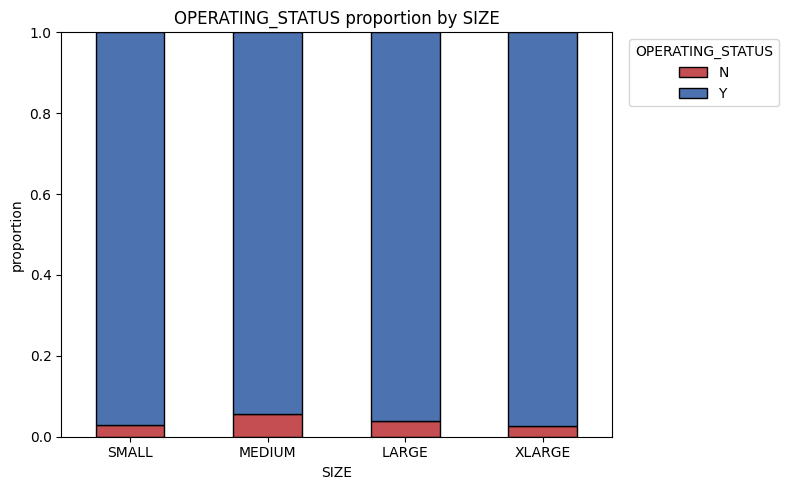

In [635]:
ax = op_prop.plot(
    kind='bar', stacked=True, figsize=(8, 5),
    color={'Y': '#4c72b0', 'N': '#c44e52'}, edgecolor='black'
)
ax.set_ylabel('proportion')
ax.set_xlabel('SIZE')
ax.set_title('OPERATING_STATUS proportion by SIZE')
ax.set_ylim(0, 1)
ax.legend(title='OPERATING_STATUS', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### AIRCRAFT_STATUS by SIZE

In [636]:
ac_prop = (
    sized.groupby('SIZE')['AIRCRAFT_STATUS']
         .value_counts(normalize=True)
         .unstack('AIRCRAFT_STATUS')
         .reindex(labels)
         .fillna(0)
)
# order columns: O(wned), A (capital lease), B (operating lease)
ac_prop = ac_prop[[c for c in ['O', 'A', 'B'] if c in ac_prop.columns]]
ac_prop

AIRCRAFT_STATUS,O,A,B
SIZE,,,
SMALL,0.750848,0.050431,0.198722
MEDIUM,0.399378,0.042232,0.558389
LARGE,0.647411,0.140856,0.211733
XLARGE,0.695264,0.068104,0.236632


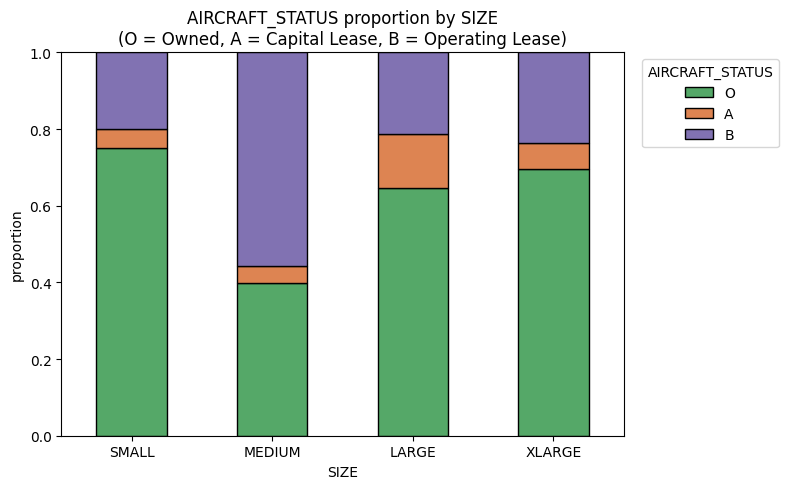

In [637]:
ax = ac_prop.plot(
    kind='bar', stacked=True, figsize=(8, 5),
    color={'O': '#55a868', 'A': '#dd8452', 'B': '#8172b2'}, edgecolor='black'
)
ax.set_ylabel('proportion')
ax.set_xlabel('SIZE')
ax.set_title('AIRCRAFT_STATUS proportion by SIZE\n(O = Owned, A = Capital Lease, B = Operating Lease)')
ax.set_ylim(0, 1)
ax.legend(title='AIRCRAFT_STATUS', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Summary

Quartile edges [0, 50], (50, 117], (117, 154] (154, 190+] seats. 

`OPERATING_STATUS` by size: Operating rates are high across the board (>95% in every bin). `XLARGE` has the highest operating rate (~97%) and `SMALL` the lowest (~95%). 

`AIRCRAFT_STATUS` by size: The lease structure is not monotonic in size.

- `SMALL` is dominated by O  at ~58% with a significant (B) share at ~37% 
- `MEDIUM` is the outlier: only ~49% Owned and ~47% Operating Lease the highest B share of any group.
- `LARGE` shifts back toward Owned (~64%) with a increases in capital Lease (A) (~15%)
- `XLARGE` has the highest Owned share (~70%).

Therefore, `SIZE` is a useful engineered feature as it correlates with operating probability and ownership.

# Task 6

Fit four regression models on the fully-cleaned frame `clean_dropped` from Task 3:

1. `NUMBER_OF_SEATS` ~ features, **linear regression**
2. `CAPACITY_IN_POUNDS` ~ features, **linear regression**
3. `NUMBER_OF_SEATS` ~ features, **random forest**
4. `CAPACITY_IN_POUNDS` ~ features, **random forest**

**Feature choice** (same set for all four models, minus the target):

- Numeric: `YEAR`, `MANUFACTURE_YEAR`, and the *other* numeric target (e.g. `CAPACITY_IN_POUNDS` when predicting `NUMBER_OF_SEATS`).
- Categorical: `MANUFACTURER` (already standardized in Task 2, ≈100 values), `AIRCRAFT_STATUS`, `OPERATING_STATUS`. One-hot encoded.
- Deliberately **not** used: `SIZE` (derived from `NUMBER_OF_SEATS` — would leak when seats is the target), `MODEL` and `AIRCRAFT_TYPE` (very high cardinality — would blow up the one-hot matrix for linear regression and isn't needed to make the point), identifiers like `TAIL_NUMBER` / `SERIAL_NUMBER` / `CARRIER` / `CARRIER_NAME` / `AIRLINE_ID` / `UNIQUE_CARRIER*`, and the `*_IMPUTE_METHOD` bookkeeping columns.

80/20 split, `random_state=42`. Report RMSE on train and test for each of the four models.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

CAT_FEATURES = ['MANUFACTURER', 'AIRCRAFT_STATUS', 'OPERATING_STATUS']
BASE_NUM = ['YEAR', 'MANUFACTURE_YEAR']

def make_preprocessor(num_features, cat_features):
    return ColumnTransformer([
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
    ])

def train_and_report(df, target, model, model_name, random_state=42):
    other_numeric = 'CAPACITY_IN_POUNDS' if target == 'NUMBER_OF_SEATS' else 'NUMBER_OF_SEATS'
    num_features = BASE_NUM + [other_numeric]
    X = df[num_features + CAT_FEATURES].copy()
    # MANUFACTURE_YEAR is a nullable Int64 from Task 1; cast to float for sklearn
    X['MANUFACTURE_YEAR'] = X['MANUFACTURE_YEAR'].astype(float)
    y = df[target].astype(float)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    pipe = Pipeline([
        ('prep', make_preprocessor(num_features, CAT_FEATURES)),
        ('model', model),
    ])
    pipe.fit(X_train, y_train)

    rmse_train = np.sqrt(mean_squared_error(y_train, pipe.predict(X_train)))
    rmse_test  = np.sqrt(mean_squared_error(y_test,  pipe.predict(X_test)))
    return {'target': target, 'model': model_name,
            'train_RMSE': rmse_train, 'test_RMSE': rmse_test}

In [ ]:
results = []

# 1 & 2: Linear Regression
results.append(train_and_report(clean_dropped, 'NUMBER_OF_SEATS',
                                LinearRegression(), 'LinearRegression'))
results.append(train_and_report(clean_dropped, 'CAPACITY_IN_POUNDS',
                                LinearRegression(), 'LinearRegression'))

# 3 & 4: Random Forest
results.append(train_and_report(clean_dropped, 'NUMBER_OF_SEATS',
                                RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
                                'RandomForest'))
results.append(train_and_report(clean_dropped, 'CAPACITY_IN_POUNDS',
                                RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
                                'RandomForest'))

results_df = pd.DataFrame(results)[['target', 'model', 'train_RMSE', 'test_RMSE']]
results_df

### Observations

Measured results (your `results_df` above):

| target              | model            | train RMSE | test RMSE |
|---------------------|------------------|-----------:|----------:|
| NUMBER_OF_SEATS     | LinearRegression |      ~49.0 |     ~48.9 |
| CAPACITY_IN_POUNDS  | LinearRegression |    ~77,260 |   ~77,430 |
| NUMBER_OF_SEATS     | RandomForest     |      ~3.5  |     ~5.5  |
| CAPACITY_IN_POUNDS  | RandomForest     |    ~50,500 |   ~54,920 |

- **Random forest crushes linear regression on both targets.** For `NUMBER_OF_SEATS`, test RMSE drops from ~49 to ~5.5 — almost an order of magnitude. For `CAPACITY_IN_POUNDS` it drops from ~77k to ~55k, a ~30% improvement. The relationships here are highly non-linear and discrete (seating configurations cluster around a handful of airframes; capacity jumps step-wise by aircraft family), which trees handle natively and a hyperplane cannot.

- **Linear regression underfits — not overfits.** Its train and test RMSEs are essentially identical (48.98 / 48.89 for seats; 77,258 / 77,430 for capacity). That near-zero train/test gap is the signature of a high-bias model: it isn't flexible enough to learn the structure in the data at all. Adding more data won't help; the model class is the limit.

- **Random forest shows mild overfitting, but it's still the right choice.** For seats, train RMSE ≈ 3.5 vs test ≈ 5.5 — a noticeable gap, driven by the fact that RF with default `max_depth=None` can memorize leaves for the most common model/manufacturer combos. For capacity, the train/test gap is much smaller (50.5k vs 54.9k, ~9%). Either way, even the overfit forest's test RMSE beats the linear model's test RMSE by a huge margin, so the trade is easily worth it.

- **Scale note**: `CAPACITY_IN_POUNDS` is measured in pounds and ranges across several orders of magnitude, so its absolute RMSE is inherently much larger than the seats RMSE — don't compare the two targets' raw RMSEs directly. The meaningful comparison is within-target (linear vs RF), and in *both* cases the forest wins.

- **Feature leakage check**: using the *other* numeric target as a feature (capacity when predicting seats, and vice versa) is legitimate here — both are observed physical properties of the same airframe, available at inference time, and genuinely co-informative. This is not the same as leaking `SIZE`, which is derived *from* `NUMBER_OF_SEATS` and was correctly excluded.